<a href="https://colab.research.google.com/github/prishachakraborty1-ops/Explainable-AI-Based-Loan-Approval-System/blob/ankita/research_internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd

In [18]:
import numpy as np

In [19]:
import seaborn as sns

In [20]:
import matplotlib.pyplot as plt

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
from sklearn.compose import ColumnTransformer

In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [24]:
df_raw = pd.read_csv("loan_approval_dataset.csv")
df_raw.columns = df_raw.columns.str.strip()
df_p2 = df_raw[df_raw['loan_id'] > 2135].copy()


In [25]:
categorical_cols = df_p2.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_p2[col] = df_p2[col].str.strip()

In [26]:
df_p2.loc[df_p2['residential_assets_value'] < 0, 'residential_assets_value'] = 0

In [27]:
df_p2['loan_status_encoded'] = df_p2['loan_status'].map({'Approved': 1, 'Rejected': 0})
numeric_df = df_p2.select_dtypes(include=[np.number]).drop(columns=['loan_id'])

print("--- Person 2: Dataset Summary ---")
print(f"Batch 2 Shape: {df_p2.shape}")
print("\nTarget Distribution:\n", df_p2['loan_status'].value_counts(normalize=True))


--- Person 2: Dataset Summary ---
Batch 2 Shape: (2134, 14)

Target Distribution:
 loan_status
Approved    0.630272
Rejected    0.369728
Name: proportion, dtype: float64


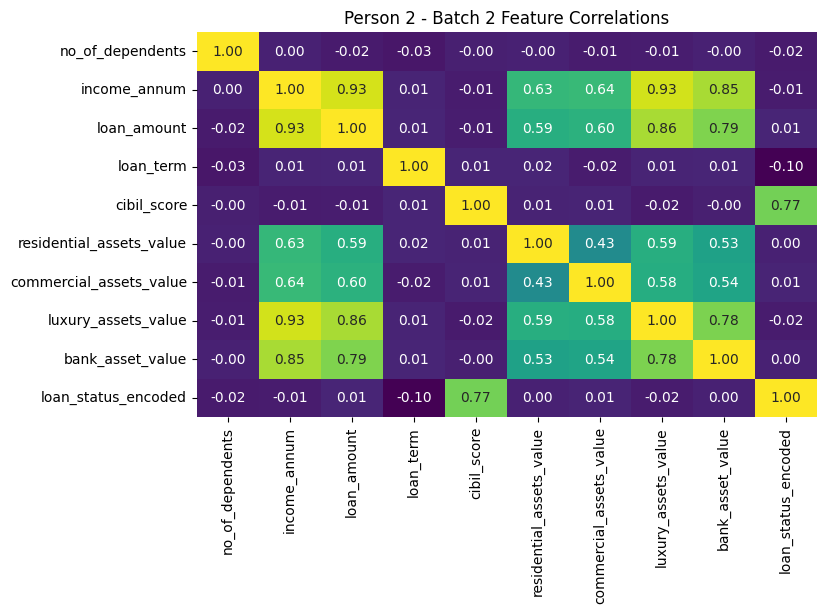

In [28]:
plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis', fmt=".2f", cbar=False)
plt.title("Person 2 - Batch 2 Feature Correlations")
plt.show()

In [29]:
X = df_p2.drop(columns=['loan_id', 'loan_status', 'loan_status_encoded'])
y = df_p2['loan_status_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_features = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
                'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
cat_features = ['education', 'self_employed']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)

In [30]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

feature_names = num_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))

train_clean = pd.DataFrame(X_train_scaled, columns=feature_names)
train_clean['target'] = y_train.values
test_clean = pd.DataFrame(X_test_scaled, columns=feature_names)
test_clean['target'] = y_test.values

train_clean.to_csv("person2_batch2_train.csv", index=False)
test_clean.to_csv("person2_batch2_test.csv", index=False)
print("\n>>> Person 2 files saved: 'person2_batch2_train.csv' and 'person2_batch2_test.csv'")


>>> Person 2 files saved: 'person2_batch2_train.csv' and 'person2_batch2_test.csv'


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [32]:
train_df = pd.read_csv("person2_batch2_train.csv")
test_df = pd.read_csv("person2_batch2_test.csv")

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']
X_test = test_df.drop(columns=['target'])
y_test = test_df['target']


In [33]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42, probability=True)
}

print("--- Person 2: Evaluating All Baseline Models ---")

--- Person 2: Evaluating All Baseline Models ---


In [34]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} ===")
    print(f"Accuracy  : {accuracy_score(y_test, preds):.4f}")
    print(f"Precision : {precision_score(y_test, preds):.4f}")
    print(f"Recall    : {recall_score(y_test, preds):.4f}")
    print(f"F1-Score  : {f1_score(y_test, preds):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_test, probs):.4f}")


=== Logistic Regression ===
Accuracy  : 0.9087
Precision : 0.9323
Recall    : 0.9219
F1-Score  : 0.9271
ROC-AUC   : 0.9656

=== Decision Tree ===
Accuracy  : 0.9625
Precision : 0.9703
Recall    : 0.9703
F1-Score  : 0.9703
ROC-AUC   : 0.9598

=== Random Forest ===
Accuracy  : 0.9625
Precision : 0.9703
Recall    : 0.9703
F1-Score  : 0.9703
ROC-AUC   : 0.9950

=== Naive Bayes ===
Accuracy  : 0.9227
Precision : 0.9538
Recall    : 0.9219
F1-Score  : 0.9376
ROC-AUC   : 0.9656

=== KNN ===
Accuracy  : 0.8759
Precision : 0.9000
Recall    : 0.9033
F1-Score  : 0.9017
ROC-AUC   : 0.9523

=== SVM ===
Accuracy  : 0.9133
Precision : 0.9361
Recall    : 0.9257
F1-Score  : 0.9308
ROC-AUC   : 0.9782
